**NLP/Language Task**

**1. Mount Drive**

In [2]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**2. Install Libraries**

In [3]:
# Install libraries
!pip install gradio --quiet
!pip install gensim --quiet

# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import re
import nltk
nltk.download('stopwords')
nltk.download('wordnet')
nltk.download('omw-1.4')
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import tensorflow as tf
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, LSTM, Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping

print("✅ All libraries imported successfully!")
print("TensorFlow version:", tf.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.9/27.9 MB 65.8 MB/s eta 0:00:00


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


✅ All libraries imported successfully!
TensorFlow version: 2.20.0


**3. Load the Dataset**

In [4]:
# Load datasets
train_df = pd.read_csv('/content/drive/MyDrive/AI & ML/AI_Assesment/train_movie_review.csv')
val_df   = pd.read_csv('/content/drive/MyDrive/AI & ML/AI_Assesment/val_movie_review.csv')
test_df  = pd.read_csv('/content/drive/MyDrive/AI & ML/AI_Assesment/test_movie_review.csv')

# Quick look at the data
print("=== TRAIN DATASET ===")
print(f"Shape: {train_df.shape}")
print(train_df.head(3))

print("\n=== VAL DATASET ===")
print(f"Shape: {val_df.shape}")
print(val_df.head(3))

print("\n=== TEST DATASET ===")
print(f"Shape: {test_df.shape}")
print(test_df.head(3))

=== TRAIN DATASET ===
Shape: (35000, 3)
   Unnamed: 0                                             review  sentiment
0        3774  Having avoided seeing the movie in the cinema,...          0
1       48396  With this movie I was really hoping that the i...          0
2        1980  Raymond Burr stars as an attorney caught up in...          0

=== VAL DATASET ===
Shape: (5000, 3)
   Unnamed: 0                                             review  sentiment
0       30825  A genuinely odd, surreal jumble of visual idea...          0
1       42564  "The Snow Queen" is based on the famous and ve...          0
2       16498  The quintessential Georgian film of Georgi Dan...          1

=== TEST DATASET ===
Shape: (10000, 3)
   Unnamed: 0                                             review  sentiment
0       33553  I really liked this Summerslam due to the look...          1
1        9427  Not many television shows appeal to quite as m...          1
2         199  The film quickly gets to a majo

**4.  Data Cleaning & Preprocessing**

=== TRAIN Sentiment Distribution ===
sentiment
0    17584
1    17416
Name: count, dtype: int64

=== VAL Sentiment Distribution ===
sentiment
1    2545
0    2455
Name: count, dtype: int64

=== TEST Sentiment Distribution ===
sentiment
1    5039
0    4961
Name: count, dtype: int64


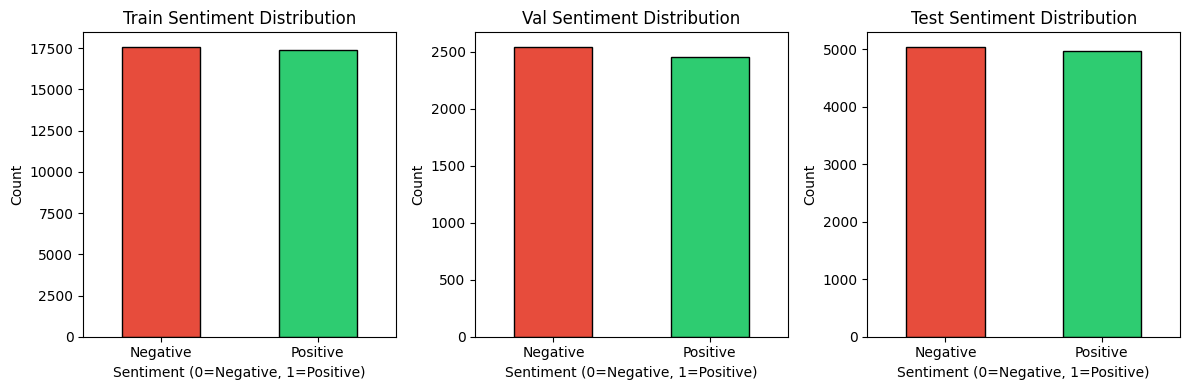

✅ Done!


In [5]:
# Drop unnamed column
train_df = train_df.drop(columns=['Unnamed: 0'])
val_df   = val_df.drop(columns=['Unnamed: 0'])
test_df  = test_df.drop(columns=['Unnamed: 0'])

# Drop any null values
train_df = train_df.dropna()
val_df   = val_df.dropna()
test_df  = test_df.dropna()

# Check class distribution
print("=== TRAIN Sentiment Distribution ===")
print(train_df['sentiment'].value_counts())

print("\n=== VAL Sentiment Distribution ===")
print(val_df['sentiment'].value_counts())

print("\n=== TEST Sentiment Distribution ===")
print(test_df['sentiment'].value_counts())

# Plot class distribution
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, df, title in zip(axes, [train_df, val_df, test_df], ['Train', 'Val', 'Test']):
    df['sentiment'].value_counts().plot(kind='bar', ax=ax, color=['#e74c3c','#2ecc71'], edgecolor='black')
    ax.set_title(f'{title} Sentiment Distribution')
    ax.set_xlabel('Sentiment (0=Negative, 1=Positive)')
    ax.set_ylabel('Count')
    ax.set_xticklabels(['Negative', 'Positive'], rotation=0)

plt.tight_layout()
plt.savefig('class_distribution.png', dpi=150)
plt.show()
print("✅ Done!")

**5.  Text Cleaning Function**

In [6]:
# Initialize lemmatizer and stopwords
lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Keep negation words - important for sentiment!
negation_words = {'no', 'not', 'nor', 'neither', 'never', "don't", "doesn't",
                  "didn't", "won't", "wouldn't", "couldn't", "shouldn't"}
stop_words = stop_words - negation_words

def clean_text(text):
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r'http\S+|www\S+', '', text)
    # Remove HTML tags
    text = re.sub(r'<.*?>', '', text)
    # Remove mentions and hashtags
    text = re.sub(r'@\w+|#\w+', '', text)
    # Handle contractions
    contractions = {
        "don't": "do not", "doesn't": "does not", "didn't": "did not",
        "won't": "will not", "wouldn't": "would not", "couldn't": "could not",
        "shouldn't": "should not", "isn't": "is not", "aren't": "are not",
        "wasn't": "was not", "weren't": "were not", "haven't": "have not",
        "hasn't": "has not", "hadn't": "had not", "it's": "it is",
        "i'm": "i am", "i've": "i have", "i'll": "i will", "i'd": "i would"
    }
    for contraction, expansion in contractions.items():
        text = text.replace(contraction, expansion)
    # Remove numbers
    text = re.sub(r'\d+', '', text)
    # Remove special characters and punctuation
    text = re.sub(r'[^\w\s]', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Tokenize
    tokens = text.split()
    # Remove stopwords and lemmatize
    tokens = [lemmatizer.lemmatize(word) for word in tokens if word not in stop_words]
    return ' '.join(tokens)

# Apply cleaning to all datasets
print("Cleaning train data... (may take a minute)")
train_df['cleaned_review'] = train_df['review'].apply(clean_text)

print("Cleaning val data...")
val_df['cleaned_review'] = val_df['review'].apply(clean_text)

print("Cleaning test data...")
test_df['cleaned_review'] = test_df['review'].apply(clean_text)

# Preview
print("\n=== Sample Original vs Cleaned ===")
print("ORIGINAL:", train_df['review'].iloc[0][:200])
print("\nCLEANED:", train_df['cleaned_review'].iloc[0][:200])
print("\n✅ Text cleaning done!")

Cleaning train data... (may take a minute)
Cleaning val data...
Cleaning test data...

=== Sample Original vs Cleaned ===
ORIGINAL: Having avoided seeing the movie in the cinema, but buying the DVD for my wife for Xmas, I had to watch it. I did not expect much, which usually means I get more than I bargained for. But 'Mamma Mia' -

CLEANED: avoided seeing movie cinema buying dvd wife xmas watch not expect much usually mean get bargained mamma mia utter utter cr like abba like song old lp film terrible stage show look like bit musical rac

✅ Text cleaning done!


**6. Visualization (Word Cloud + Top Words)**

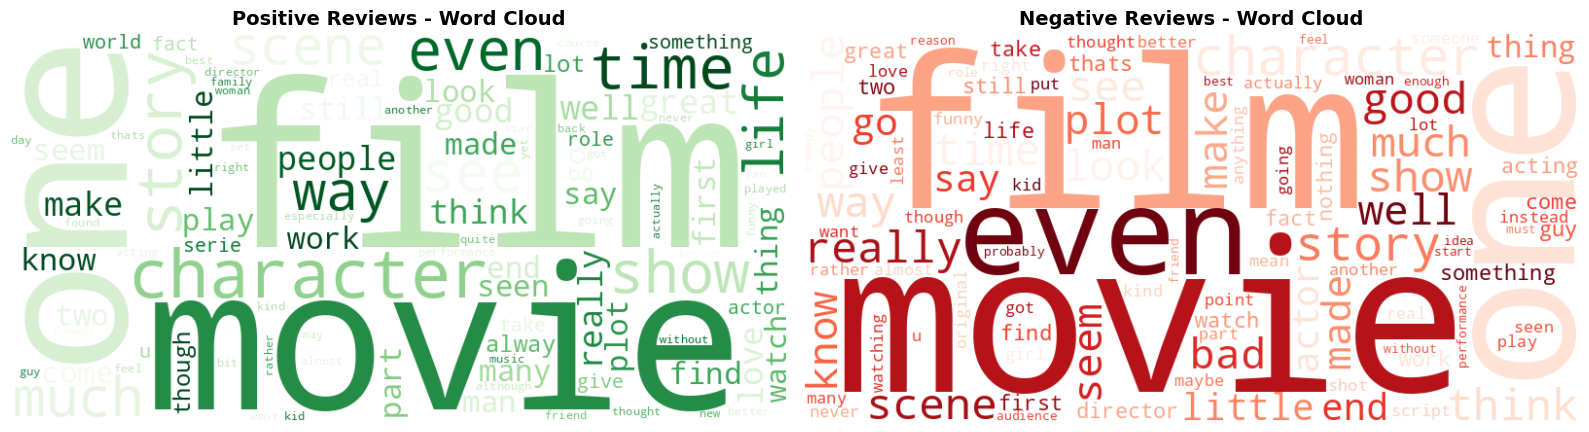

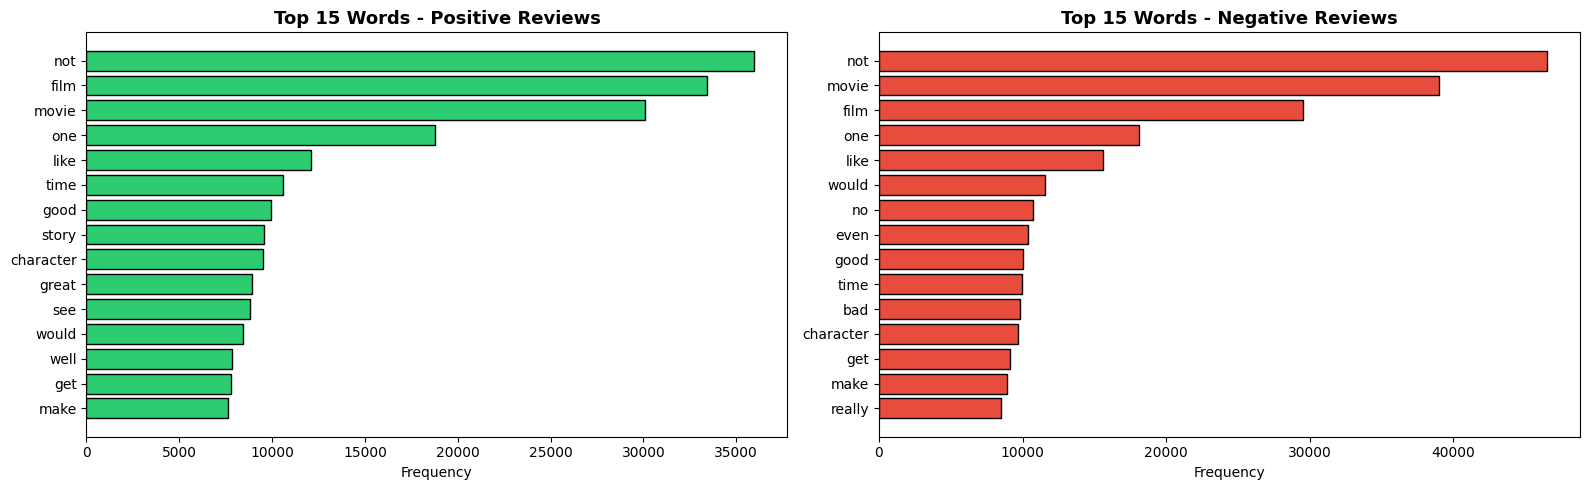

✅ Visualizations done!


In [7]:
# Separate positive and negative reviews
pos_reviews = ' '.join(train_df[train_df['sentiment']==1]['cleaned_review'])
neg_reviews = ' '.join(train_df[train_df['sentiment']==0]['cleaned_review'])

# --- Word Clouds ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Positive wordcloud
pos_wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap='Greens',
                   max_words=100).generate(pos_reviews)
axes[0].imshow(pos_wc, interpolation='bilinear')
axes[0].set_title('Positive Reviews - Word Cloud', fontsize=14, fontweight='bold')
axes[0].axis('off')

# Negative wordcloud
neg_wc = WordCloud(width=800, height=400,
                   background_color='white',
                   colormap='Reds',
                   max_words=100).generate(neg_reviews)
axes[1].imshow(neg_wc, interpolation='bilinear')
axes[1].set_title('Negative Reviews - Word Cloud', fontsize=14, fontweight='bold')
axes[1].axis('off')

plt.tight_layout()
plt.savefig('wordclouds.png', dpi=150)
plt.show()

# --- Top 15 Most Frequent Words ---
from collections import Counter

pos_words = Counter(pos_reviews.split()).most_common(15)
neg_words = Counter(neg_reviews.split()).most_common(15)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Positive top words
words, counts = zip(*pos_words)
axes[0].barh(words, counts, color='#2ecc71', edgecolor='black')
axes[0].set_title('Top 15 Words - Positive Reviews', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Frequency')
axes[0].invert_yaxis()

# Negative top words
words, counts = zip(*neg_words)
axes[1].barh(words, counts, color='#e74c3c', edgecolor='black')
axes[1].set_title('Top 15 Words - Negative Reviews', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Frequency')
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig('top_words.png', dpi=150)
plt.show()

print("✅ Visualizations done!")

**7. Tokenization & Padding**

In [8]:
# Define features and labels
X_train = train_df['cleaned_review'].values
y_train = train_df['sentiment'].values

X_val = val_df['cleaned_review'].values
y_val = val_df['sentiment'].values

X_test = test_df['cleaned_review'].values
y_test = test_df['sentiment'].values

# --- Tokenization ---
VOCAB_SIZE = 20000  # Top 20000 most frequent words

tokenizer = Tokenizer(num_words=VOCAB_SIZE, oov_token='<OOV>')
tokenizer.fit_on_texts(X_train)  # Fit only on training data

# Convert text to sequences
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_val_seq   = tokenizer.texts_to_sequences(X_val)
X_test_seq  = tokenizer.texts_to_sequences(X_test)

# --- Check sequence lengths for padding ---
lengths = [len(seq) for seq in X_train_seq]
print(f"Max sequence length  : {max(lengths)}")
print(f"Mean sequence length : {int(np.mean(lengths))}")
print(f"90th percentile      : {int(np.percentile(lengths, 90))}")
print(f"95th percentile      : {int(np.percentile(lengths, 95))}")

# Use 95th percentile to avoid very long sequences
MAX_LEN = int(np.percentile(lengths, 95))
print(f"\n✅ Using MAX_LEN = {MAX_LEN}")

# --- Padding ---
X_train_pad = pad_sequences(X_train_seq, maxlen=MAX_LEN, padding='post', truncating='post')
X_val_pad   = pad_sequences(X_val_seq,   maxlen=MAX_LEN, padding='post', truncating='post')
X_test_pad  = pad_sequences(X_test_seq,  maxlen=MAX_LEN, padding='post', truncating='post')

print(f"\nX_train shape : {X_train_pad.shape}")
print(f"X_val shape   : {X_val_pad.shape}")
print(f"X_test shape  : {X_test_pad.shape}")
print("\n✅ Tokenization and Padding done!")

Max sequence length  : 1425
Mean sequence length : 119
90th percentile      : 235
95th percentile      : 308

✅ Using MAX_LEN = 308

X_train shape : (35000, 308)
X_val shape   : (5000, 308)
X_test shape  : (10000, 308)

✅ Tokenization and Padding done!


**8. Build Model 1 (Simple RNN)**

In [9]:
# Define embedding dimension
EMBED_DIM = 64

# --- Model 1: Simple RNN ---
model1 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM, input_length=MAX_LEN),
    SimpleRNN(64, return_sequences=False),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model1.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model1.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

**9. Train Model 1 (Simple RNN)**

In [10]:
# Early stopping to prevent overfitting
early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("Training Model 1 - Simple RNN...")
print("="*50)

history1 = model1.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop],
    verbose=1
)

print("\n✅ Model 1 Training Done!")

Training Model 1 - Simple RNN...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 16s 41ms/step - accuracy: 0.4973 - loss: 0.6957 - val_accuracy: 0.5026 - val_loss: 0.6936
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5055 - loss: 0.6944 - val_accuracy: 0.4924 - val_loss: 0.6943
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.4955 - loss: 0.6988 - val_accuracy: 0.5088 - val_loss: 0.6931
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.4989 - loss: 0.6963 - val_accuracy: 0.4946 - val_loss: 0.6949
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.4993 - loss: 0.6954 - val_accuracy: 0.4994 - val_loss: 0.6936
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.5000 - loss: 0.6946 - val_accuracy: 0.5028 - val_loss: 0.6934
Epoch 6: early stopping
Restoring model weights from the end of the best epoch: 3.

✅ Model 1 Training Done!


**10. Evaluate Model 1 & Plot Results**

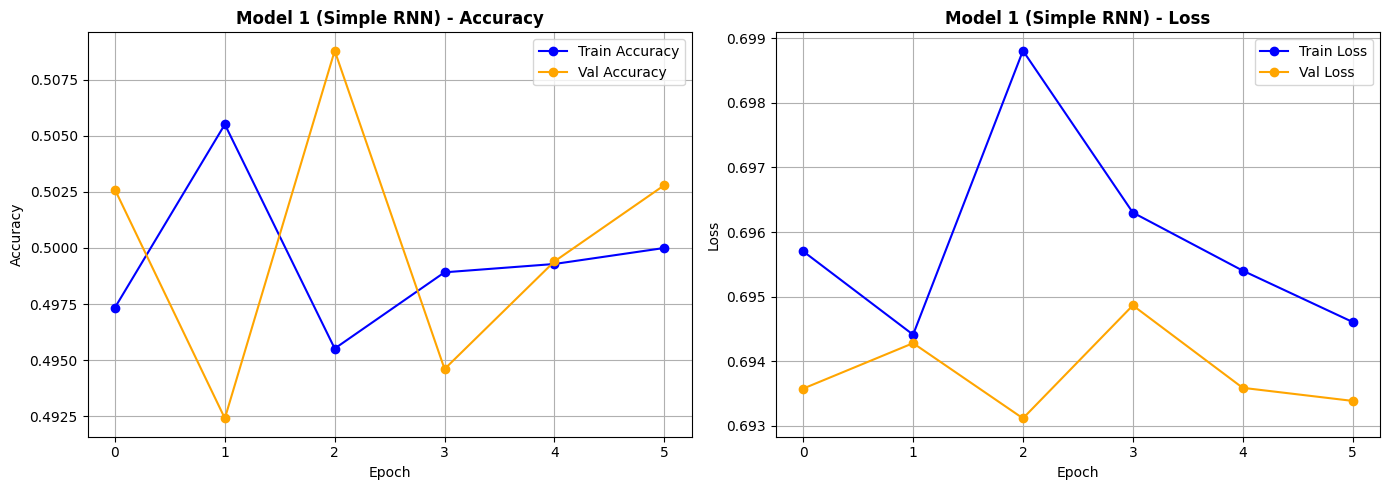

=== Model 1 - Simple RNN Evaluation ===

Test Accuracy : 0.5127
Test Loss     : 0.6926
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.52      0.24      0.33      4961
    Positive       0.51      0.78      0.62      5039

    accuracy                           0.51     10000
   macro avg       0.52      0.51      0.47     10000
weighted avg       0.52      0.51      0.47     10000



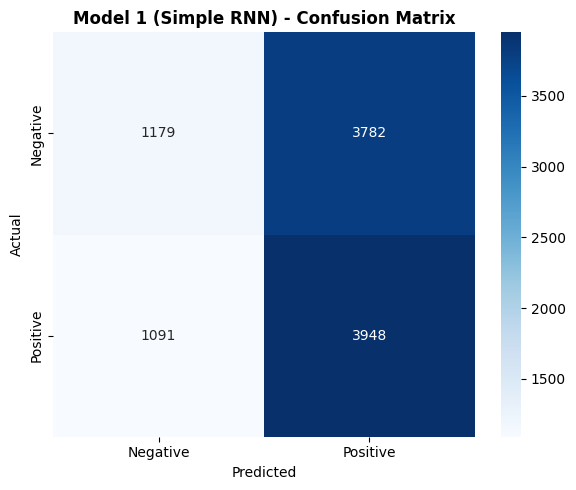

✅ Model 1 Evaluation Done!


In [11]:
# --- Plot Training History ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history1.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
axes[0].plot(history1.history['val_accuracy'], label='Val Accuracy', color='orange', marker='o')
axes[0].set_title('Model 1 (Simple RNN) - Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history1.history['loss'], label='Train Loss', color='blue', marker='o')
axes[1].plot(history1.history['val_loss'], label='Val Loss', color='orange', marker='o')
axes[1].set_title('Model 1 (Simple RNN) - Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('model1_history.png', dpi=150)
plt.show()

# --- Evaluate on Test Set ---
print("=== Model 1 - Simple RNN Evaluation ===\n")
loss1, acc1 = model1.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy : {acc1:.4f}")
print(f"Test Loss     : {loss1:.4f}")

# Predictions
y_pred1 = (model1.predict(X_test_pad) > 0.5).astype(int)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred1, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm1 = confusion_matrix(y_test, y_pred1)
plt.figure(figsize=(6, 5))
sns.heatmap(cm1, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Model 1 (Simple RNN) - Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('model1_confusion_matrix.png', dpi=150)
plt.show()

print("✅ Model 1 Evaluation Done!")

**11.  Build & Train Model 2 (LSTM)**

In [12]:
# --- Model 2: LSTM with trainable Embedding ---
model2 = Sequential([
    Embedding(input_dim=VOCAB_SIZE, output_dim=EMBED_DIM),
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(32),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model2.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model2.summary()

# Train
early_stop2 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining Model 2 - LSTM...")
print("="*50)

history2 = model2.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop2],
    verbose=1
)

print("\n✅ Model 2 Training Done!")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_1 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)


Training Model 2 - LSTM...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 15s 28ms/step - accuracy: 0.5012 - loss: 0.6934 - val_accuracy: 0.5090 - val_loss: 0.6929
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 31ms/step - accuracy: 0.5078 - loss: 0.6917 - val_accuracy: 0.4996 - val_loss: 0.6919
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 7s 27ms/step - accuracy: 0.5233 - loss: 0.6786 - val_accuracy: 0.5028 - val_loss: 0.6977
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5271 - loss: 0.6642 - val_accuracy: 0.5040 - val_loss: 0.7063
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - accuracy: 0.5299 - loss: 0.6574 - val_accuracy: 0.5108 - val_loss: 0.7428
Epoch 5: early stopping
Restoring model weights from the end of the best epoch: 2.

✅ Model 2 Training Done!


**12. Evaluate Model 2 (LSTM)**

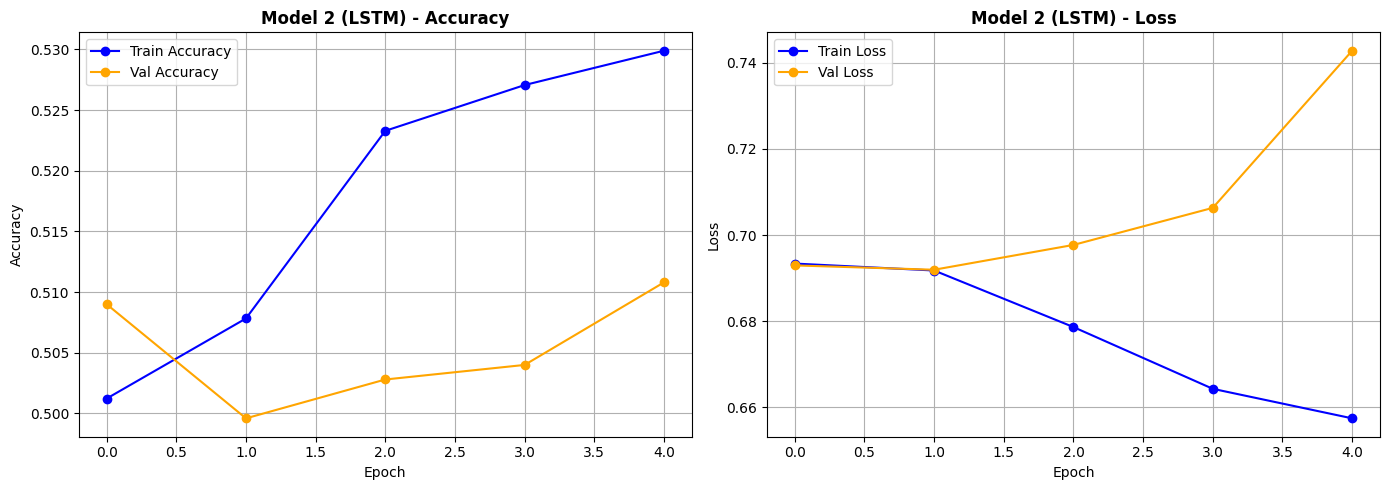

=== Model 2 - LSTM Evaluation ===

Test Accuracy : 0.5051
Test Loss     : 0.6906
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 12ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.50      0.97      0.66      4961
    Positive       0.60      0.05      0.10      5039

    accuracy                           0.51     10000
   macro avg       0.55      0.51      0.38     10000
weighted avg       0.55      0.51      0.38     10000



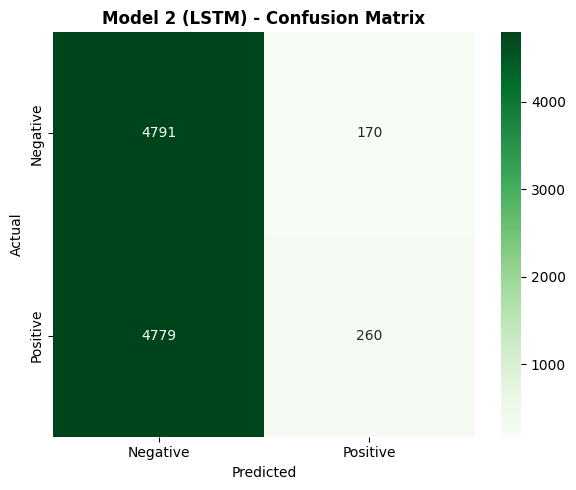

✅ Model 2 Evaluation Done!


In [13]:
# --- Plot Training History ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy plot
axes[0].plot(history2.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
axes[0].plot(history2.history['val_accuracy'], label='Val Accuracy', color='orange', marker='o')
axes[0].set_title('Model 2 (LSTM) - Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

# Loss plot
axes[1].plot(history2.history['loss'], label='Train Loss', color='blue', marker='o')
axes[1].plot(history2.history['val_loss'], label='Val Loss', color='orange', marker='o')
axes[1].set_title('Model 2 (LSTM) - Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('model2_history.png', dpi=150)
plt.show()

# --- Evaluate on Test Set ---
print("=== Model 2 - LSTM Evaluation ===\n")
loss2, acc2 = model2.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy : {acc2:.4f}")
print(f"Test Loss     : {loss2:.4f}")

# Predictions
y_pred2 = (model2.predict(X_test_pad) > 0.5).astype(int)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred2, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm2 = confusion_matrix(y_test, y_pred2)
plt.figure(figsize=(6, 5))
sns.heatmap(cm2, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Model 2 (LSTM) - Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('model2_confusion_matrix.png', dpi=150)
plt.show()

print("✅ Model 2 Evaluation Done!")

**13. Load GloVe Embeddings & Build Embedding Matrix**

In [14]:
# Install and setup gensim for Word2Vec
import gensim.downloader as api

print("Downloading GloVe embeddings... (this may take 3-5 minutes)")
embedding_model = api.load('glove-wiki-gigaword-100')  # 100-dimensional
print("✅ GloVe embeddings loaded!")

# Build embedding matrix
EMBED_DIM_W2V = 100  # Must match glove dimension

word_index = tokenizer.word_index
embedding_matrix = np.zeros((VOCAB_SIZE, EMBED_DIM_W2V))

found = 0
not_found = 0
for word, i in word_index.items():
    if i < VOCAB_SIZE:
        if word in embedding_model:
            embedding_matrix[i] = embedding_model[word]
            found += 1
        else:
            not_found += 1

print(f"\nWords found in GloVe    : {found}")
print(f"Words not found in GloVe: {not_found}")
print(f"Embedding matrix shape  : {embedding_matrix.shape}")
print("✅ Embedding matrix built!")

[==================================================] 100.0% 128.1/128.1MB downloaded
✅ GloVe embeddings loaded!

Words found in GloVe    : 19041
Words not found in GloVe: 958
Embedding matrix shape  : (20000, 100)
✅ Embedding matrix built!


**14. Build & Train Model 3 (LSTM + GloVe)**

In [15]:
# ============================================================
# 14. Build & Train Model 3 - LSTM + GloVe (trainable=True)
# ============================================================

model3 = Sequential([
    Embedding(input_dim=VOCAB_SIZE,
              output_dim=EMBED_DIM_W2V,
              weights=[embedding_matrix],
              trainable=True),        # fine-tune embeddings
    LSTM(64, return_sequences=True),
    Dropout(0.5),
    LSTM(32),
    Dropout(0.5),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

model3.compile(
    loss='binary_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

model3.summary()

early_stop3 = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

print("\nTraining Model 3 - LSTM + GloVe...")
print("="*50)

history3 = model3.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=128,
    validation_data=(X_val_pad, y_val),
    callbacks=[early_stop3],
    verbose=1
)

print("\n✅ Model 3 Training Done!")

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_2 (Embedding)         │ ?                      │     2,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_2 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_3 (LSTM)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,000,000 (7.63 MB)

 Trainable params: 2,000,000 (7.63 MB)

 Non-trainable params: 0 (0.00 B)


Training Model 3 - LSTM + GloVe...
Epoch 1/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 12s 35ms/step - accuracy: 0.5037 - loss: 0.6930 - val_accuracy: 0.4982 - val_loss: 0.6925
Epoch 2/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5128 - loss: 0.6885 - val_accuracy: 0.5084 - val_loss: 0.6860
Epoch 3/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5203 - loss: 0.6867 - val_accuracy: 0.5092 - val_loss: 0.6845
Epoch 4/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5170 - loss: 0.6877 - val_accuracy: 0.5218 - val_loss: 0.6879
Epoch 5/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5251 - loss: 0.6767 - val_accuracy: 0.5118 - val_loss: 0.6840
Epoch 6/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 8s 30ms/step - accuracy: 0.5375 - loss: 0.6752 - val_accuracy: 0.4960 - val_loss: 0.6922
Epoch 7/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 32ms/step - accuracy: 0.5205 - loss: 0.6704 - val_accuracy: 0.5212 - val_loss: 0.6930
Epoch 8/10
274/274 ━━━━━━━━━━━━━━━━━━━━ 9s 28ms/step - accur

**15. Evaluate Model 3 (LSTM + GloVe)**

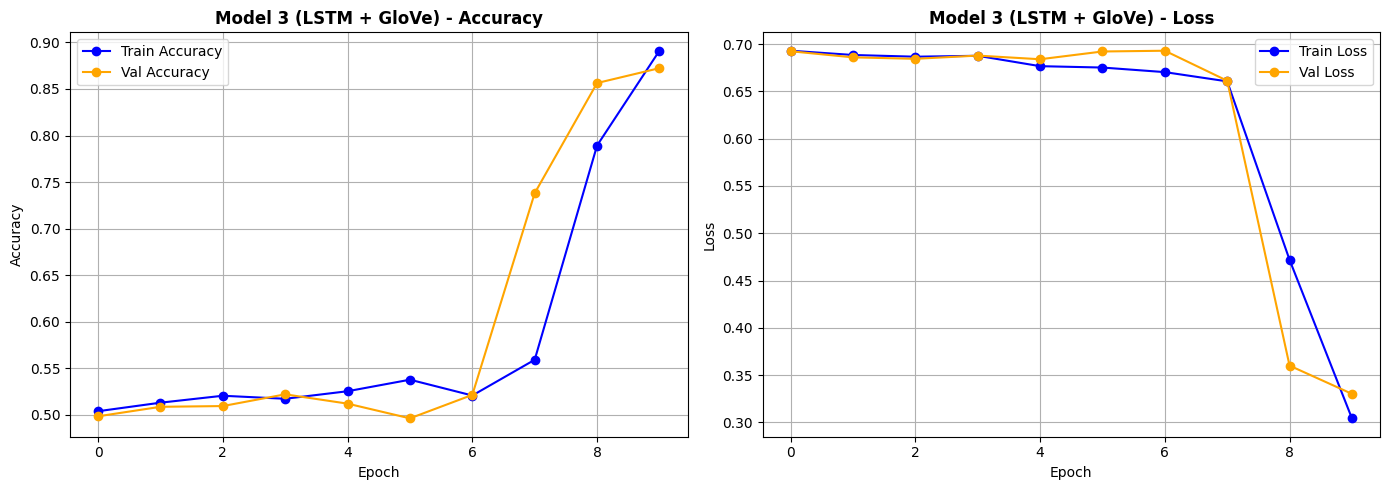

=== Model 3 - LSTM + GloVe Evaluation ===

Test Accuracy : 0.8723
Test Loss     : 0.3285
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step

Classification Report:
              precision    recall  f1-score   support

    Negative       0.89      0.85      0.87      4961
    Positive       0.86      0.89      0.88      5039

    accuracy                           0.87     10000
   macro avg       0.87      0.87      0.87     10000
weighted avg       0.87      0.87      0.87     10000



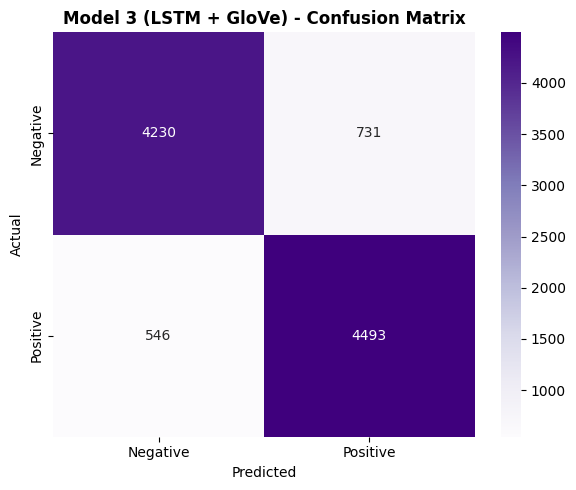

✅ Model 3 Evaluation Done!


In [16]:
# ============================================================
# 15. Evaluate Model 3 - LSTM + GloVe
# ============================================================

# --- Plot Training History ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history3.history['accuracy'], label='Train Accuracy', color='blue', marker='o')
axes[0].plot(history3.history['val_accuracy'], label='Val Accuracy', color='orange', marker='o')
axes[0].set_title('Model 3 (LSTM + GloVe) - Accuracy', fontweight='bold')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history3.history['loss'], label='Train Loss', color='blue', marker='o')
axes[1].plot(history3.history['val_loss'], label='Val Loss', color='orange', marker='o')
axes[1].set_title('Model 3 (LSTM + GloVe) - Loss', fontweight='bold')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('model3_history.png', dpi=150)
plt.show()

# --- Evaluate on Test Set ---
print("=== Model 3 - LSTM + GloVe Evaluation ===\n")
loss3, acc3 = model3.evaluate(X_test_pad, y_test, verbose=0)
print(f"Test Accuracy : {acc3:.4f}")
print(f"Test Loss     : {loss3:.4f}")

# Predictions
y_pred3 = (model3.predict(X_test_pad) > 0.5).astype(int)

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred3, target_names=['Negative', 'Positive']))

# Confusion Matrix
cm3 = confusion_matrix(y_test, y_pred3)
plt.figure(figsize=(6, 5))
sns.heatmap(cm3, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Negative', 'Positive'],
            yticklabels=['Negative', 'Positive'])
plt.title('Model 3 (LSTM + GloVe) - Confusion Matrix', fontweight='bold')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.tight_layout()
plt.savefig('model3_confusion_matrix.png', dpi=150)
plt.show()
print("✅ Model 3 Evaluation Done!")

**16. Compare All 3 Models**

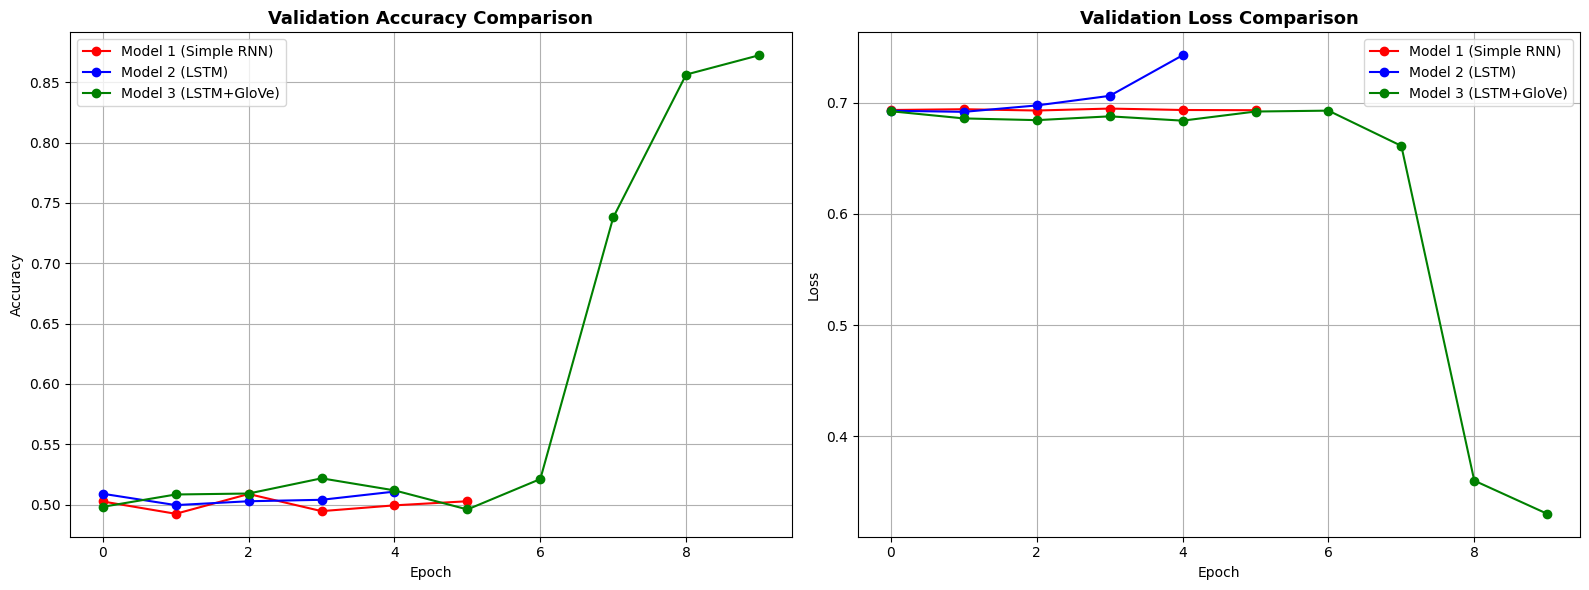

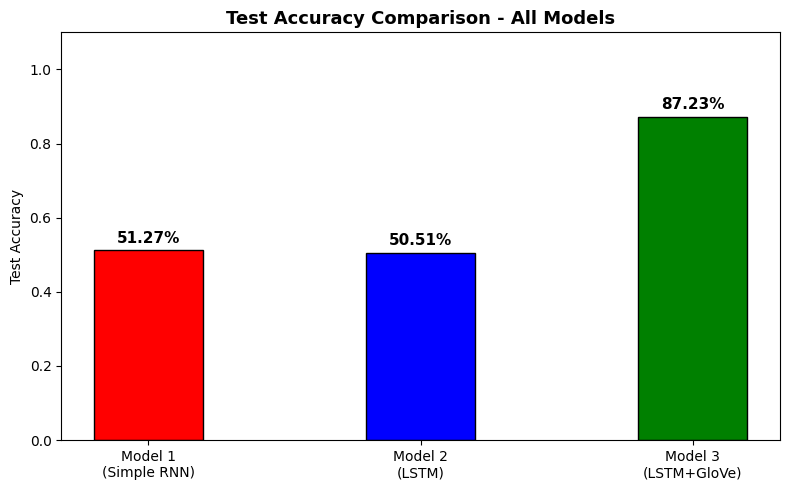


📊 Final Summary Table:
Model                       Test Accuracy    Test Loss
-------------------------------------------------------
Model 1 - Simple RNN               51.27%       0.6926
Model 2 - LSTM                     50.51%       0.6906
Model 3 - LSTM + GloVe             87.23%       0.3285

✅ Comparison Done!


In [17]:
# ============================================================
# 16. Compare All 3 Models - Combined Visualization
# ============================================================

# --- Validation Accuracy & Loss Comparison ---
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].plot(history1.history['val_accuracy'], label='Model 1 (Simple RNN)', color='red', marker='o')
axes[0].plot(history2.history['val_accuracy'], label='Model 2 (LSTM)', color='blue', marker='o')
axes[0].plot(history3.history['val_accuracy'], label='Model 3 (LSTM+GloVe)', color='green', marker='o')
axes[0].set_title('Validation Accuracy Comparison', fontweight='bold', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True)

axes[1].plot(history1.history['val_loss'], label='Model 1 (Simple RNN)', color='red', marker='o')
axes[1].plot(history2.history['val_loss'], label='Model 2 (LSTM)', color='blue', marker='o')
axes[1].plot(history3.history['val_loss'], label='Model 3 (LSTM+GloVe)', color='green', marker='o')
axes[1].set_title('Validation Loss Comparison', fontweight='bold', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150)
plt.show()

# --- Bar Chart: Test Accuracy Comparison ---
model_names = ['Model 1\n(Simple RNN)', 'Model 2\n(LSTM)', 'Model 3\n(LSTM+GloVe)']
test_accuracies = [acc1, acc2, acc3]

plt.figure(figsize=(8, 5))
bars = plt.bar(model_names, test_accuracies,
               color=['red', 'blue', 'green'],
               edgecolor='black', width=0.4)
plt.ylim(0, 1.1)
plt.title('Test Accuracy Comparison - All Models', fontweight='bold', fontsize=13)
plt.ylabel('Test Accuracy')
for bar, acc in zip(bars, test_accuracies):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 0.02,
             f'{acc*100:.2f}%',
             ha='center', fontweight='bold', fontsize=11)
plt.tight_layout()
plt.savefig('accuracy_bar_comparison.png', dpi=150)
plt.show()

# --- Summary Table ---
print("\n📊 Final Summary Table:")
print(f"{'Model':<25} {'Test Accuracy':>15} {'Test Loss':>12}")
print("-" * 55)
print(f"{'Model 1 - Simple RNN':<25} {acc1*100:>14.2f}% {loss1:>12.4f}")
print(f"{'Model 2 - LSTM':<25} {acc2*100:>14.2f}% {loss2:>12.4f}")
print(f"{'Model 3 - LSTM + GloVe':<25} {acc3*100:>14.2f}% {loss3:>12.4f}")
print("\n✅ Comparison Done!")

**17. Error Analysis**

In [18]:
# ============================================================
# 17. Error Analysis - Misclassified Examples
# ============================================================

import numpy as np

# Use Model 3 (best model) for error analysis
y_pred3_prob = model3.predict(X_test_pad, verbose=0)
y_pred3_labels = (y_pred3_prob > 0.5).astype(int).flatten()
y_test_np = np.array(y_test)

# Find misclassified indices
misclassified_idx = np.where(y_pred3_labels != y_test_np)[0]
print(f"Total Misclassified: {len(misclassified_idx)} out of {len(y_test_np)}")
print(f"Error Rate: {len(misclassified_idx)/len(y_test_np)*100:.2f}%\n")

# Get original test reviews
test_reviews = test_df['review'].values

# Show 3 misclassified examples
print("=" * 70)
print("MISCLASSIFIED EXAMPLES")
print("=" * 70)

for i, idx in enumerate(misclassified_idx[:3]):
    actual = "Positive" if y_test_np[idx] == 1 else "Negative"
    predicted = "Positive" if y_pred3_labels[idx] == 1 else "Negative"
    confidence = y_pred3_prob[idx][0]

    print(f"\n🔴 Example {i+1}:")
    print(f"   Review   : {test_reviews[idx][:300]}...")
    print(f"   Actual   : {actual}")
    print(f"   Predicted: {predicted}")
    print(f"   Confidence: {confidence:.4f}")
    print("-" * 70)

# --- False Positives and False Negatives count ---
false_positives = np.sum((y_pred3_labels == 1) & (y_test_np == 0))
false_negatives = np.sum((y_pred3_labels == 0) & (y_test_np == 1))

print(f"\n📊 Error Breakdown:")
print(f"   False Positives (predicted Positive, actually Negative): {false_positives}")
print(f"   False Negatives (predicted Negative, actually Positive): {false_negatives}")

print("\n📝 Possible Reasons for Errors:")
print("   1. Sarcasm or irony in reviews confuses the model.")
print("   2. Mixed sentiment reviews (positive start, negative end).")
print("   3. Domain-specific words not well represented in GloVe.")
print("   4. Very short or very long reviews outside typical training range.")

print("\n💡 Suggested Improvements:")
print("   1. Use transformer-based models (e.g., BERT) for better context understanding.")
print("   2. Apply attention mechanisms to focus on key sentiment words.")
print("   3. Train on larger and more diverse datasets.")
print("   4. Use domain-specific embeddings trained on movie review data.")

print("\n✅ Error Analysis Done!")

Total Misclassified: 1277 out of 10000
Error Rate: 12.77%

MISCLASSIFIED EXAMPLES

🔴 Example 1:
   Review   : I really liked this Summerslam due to the look of the arena, the curtains and just the look overall was interesting to me for some reason. Anyways, this could have been one of the best Summerslam's ever if the WWF didn't have Lex Luger in the main event against Yokozuna, now for it's time it was ok ...
   Actual   : Positive
   Predicted: Negative
   Confidence: 0.0240
----------------------------------------------------------------------

🔴 Example 2:
   Review   : Okay, I didn't get the Purgatory thing the first time I watched this episode. It seemed like something significant was going on that I couldn't put my finger on. This time those Costa Mesa fires on TV really caught my attention- and it helped that I was just writing an essay on Inferno! But let me s...
   Actual   : Positive
   Predicted: Negative
   Confidence: 0.0525
-----------------------------------------------

**18. GUI - Real Time Sentiment Prediction (Gradio)**

In [19]:
# ============================================================
# 18. GUI - Real Time Sentiment Prediction (Gradio)
# ============================================================

import gradio as gr
import numpy as np
from tensorflow.keras.preprocessing.sequence import pad_sequences

def predict_sentiment(review_text):
    # Clean the input text using same cleaning function
    cleaned = clean_text(review_text)

    # Tokenize and pad
    sequence = tokenizer.texts_to_sequences([cleaned])
    padded = pad_sequences(sequence, maxlen=MAX_LEN, padding='post', truncating='post')

    # Predict using best model (Model 3)
    prediction = model3.predict(padded, verbose=0)[0][0]

    # Result
    if prediction >= 0.5:
        sentiment = "🟢 POSITIVE"
        confidence = prediction
    else:
        sentiment = "🔴 NEGATIVE"
        confidence = 1 - prediction

    return (
        f"Sentiment  : {sentiment}\n"
        f"Confidence : {confidence*100:.2f}%\n"
        f"Raw Score  : {prediction:.4f}\n\n"
        f"Cleaned Text: {cleaned[:200]}..."
    )

# Sample examples
examples = [
    ["This movie was absolutely fantastic! The acting was superb and the story kept me hooked."],
    ["Terrible film. Waste of time and money. The plot made no sense at all."],
    ["It was okay, not great but not terrible either. Some parts were enjoyable."],
    ["One of the best movies I have ever seen. A true masterpiece!"],
    ["I can't believe how bad this was. The worst movie of the year."]
]

# Build Gradio Interface
demo = gr.Interface(
    fn=predict_sentiment,
    inputs=gr.Textbox(
        lines=5,
        placeholder="Enter a movie review here...",
        label="Movie Review"
    ),
    outputs=gr.Textbox(
        lines=6,
        label="Prediction Result"
    ),
    title="🎬 Movie Review Sentiment Analyzer",
    description="Enter a movie review and the model will predict whether it is Positive or Negative using LSTM + GloVe embeddings.",
    examples=examples,
    theme=gr.themes.Soft()
)

demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://e7934d05118f6e8d71.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
